# Vector 06: Behavioral Micro-Mimicry
**Surface:** Endpoint & Auth | **Target:** Biometric Cadence | **Defense:** XGBoost Tabular Classifier

---
**Mastercard Innovation Challenge 2026** — AI Red-Team / Blue-Team Defense Lab  
Attack: AI-driven bots study legitimate user behavioral biometrics (keystroke dynamics, mouse movement, scroll jerk, touch pressure) and generate micro-mimicry profiles that bypass behavioral authentication layers at checkout.

## Section 1 — Simulation Engine
Generate 1 000 behavioral session records: 500 human users and 500 adversarial bot sessions applying micro-mimicry.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

N = 500

# --- Legitimate human behavioral biometrics ---
legit = {
    'keystroke_dwell_mean':      np.random.normal(120, 25, N),
    'keystroke_flight_std':      np.abs(np.random.normal(45, 15, N)),
    'mouse_velocity_cv':         np.clip(np.random.normal(0.55, 0.12, N), 0.05, 1.5),
    'scroll_jerk_rms':           np.random.gamma(3, 8, N),
    'touch_pressure_cv':         np.clip(np.random.normal(0.22, 0.07, N), 0.01, 1.0),
    'rhythm_entropy':            np.clip(np.random.normal(3.8, 0.5, N), 0.5, 6.0),
    'click_interval_regularity': np.random.beta(2, 5, N),
    'session_duration_zscore':   np.random.normal(0.0, 1.0, N),
}

# --- Adversarial bot micro-mimicry sessions ---
adv = {
    'keystroke_dwell_mean':      np.clip(np.random.normal(95, 8, N), 10, 500),
    'keystroke_flight_std':      np.abs(np.random.normal(12, 4, N)),
    'mouse_velocity_cv':         np.clip(np.random.normal(0.18, 0.06, N), 0.01, 1.5),
    'scroll_jerk_rms':           np.random.gamma(1.2, 4, N),
    'touch_pressure_cv':         np.clip(np.random.normal(0.04, 0.02, N), 0.001, 1.0),
    'rhythm_entropy':            np.clip(np.random.normal(2.1, 0.4, N), 0.5, 6.0),
    'click_interval_regularity': np.random.beta(8, 2, N),
    'session_duration_zscore':   np.clip(np.random.normal(-1.8, 0.6, N), -5.0, 3.0),
}

# Clip all to reasonable positive ranges
for key in ['keystroke_dwell_mean', 'keystroke_flight_std', 'scroll_jerk_rms']:
    legit[key] = np.clip(legit[key], 1, None)
    adv[key]   = np.clip(adv[key],   0, None)

df_legit = pd.DataFrame(legit)
df_legit['label'] = 0
df_adv   = pd.DataFrame(adv)
df_adv['label'] = 1

df = pd.concat([df_legit, df_adv], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(f'Label distribution:\n{df["label"].value_counts()}')
df.describe().round(3)

Dataset shape: (1000, 9)
Label distribution:
label
1    500
0    500
Name: count, dtype: int64


,keystroke_dwell_mean,keystroke_flight_std,mouse_velocity_cv,scroll_jerk_rms,touch_pressure_cv,rhythm_entropy,click_interval_regularity,session_duration_zscore,label
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.0
mean,107.400,28.618,0.371,14.243,0.131,2.956,0.539,-0.923,0.5
std,22.319,19.998,0.215,13.570,0.103,0.946,0.292,1.203,0.5
min,38.968,1.170,0.010,0.039,0.001,1.092,0.005,-3.825,0.0
25%,92.108,11.574,0.179,3.275,0.041,2.124,0.268,-1.858,0.0
50%,100.702,18.867,0.309,9.627,0.084,2.824,0.578,-1.147,0.5
75%,120.317,45.426,0.564,21.994,0.221,3.766,0.820,-0.053,1.0
max,216.318,84.486,0.862,76.196,0.434,5.183,0.994,2.936,1.0


## Section 2 — Distribution Visualization
Overlapping KDE plots for `rhythm_entropy` and `mouse_velocity_cv`, plus a bar chart for `click_interval_regularity` quantile bands.

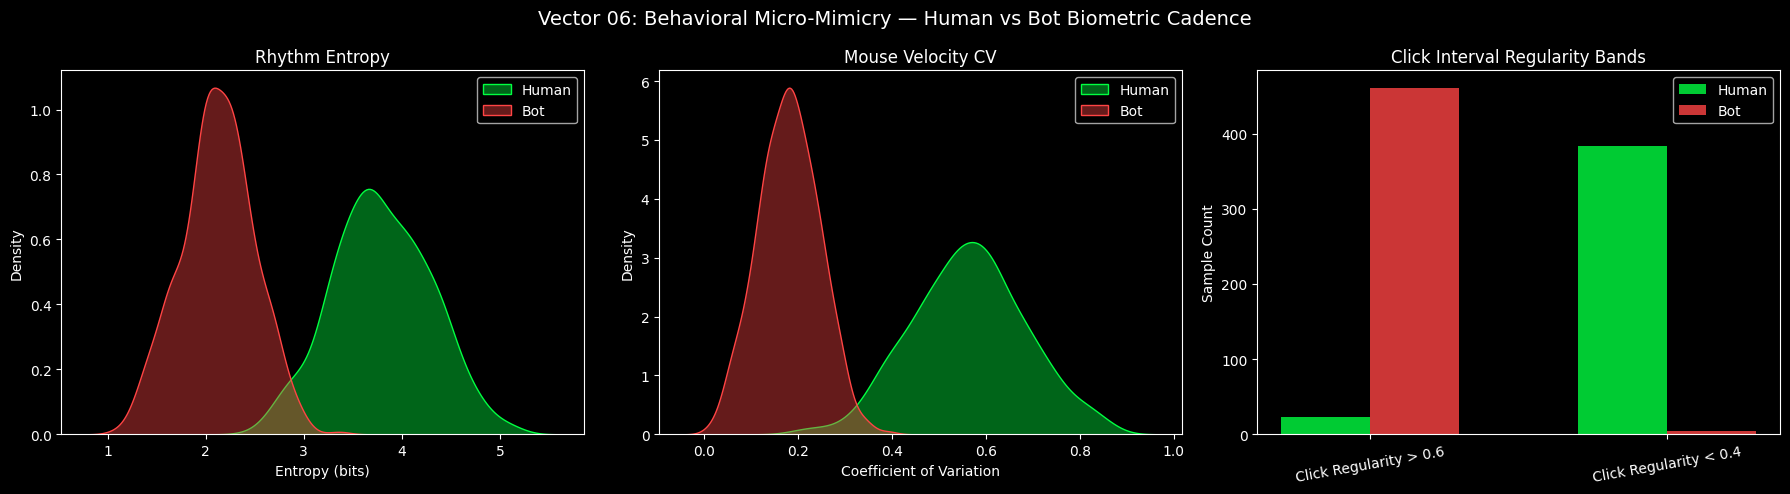

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
LEGIT_COLOR = '#00FF41'
ADV_COLOR   = '#FF4444'

legit_df = df[df['label'] == 0]
adv_df   = df[df['label'] == 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Vector 06: Behavioral Micro-Mimicry — Human vs Bot Biometric Cadence', fontsize=14, color='white')

# KDE: rhythm_entropy
sns.kdeplot(legit_df['rhythm_entropy'], ax=axes[0], color=LEGIT_COLOR, fill=True, alpha=0.4, label='Human')
sns.kdeplot(adv_df['rhythm_entropy'],   ax=axes[0], color=ADV_COLOR,   fill=True, alpha=0.4, label='Bot')
axes[0].set_title('Rhythm Entropy', color='white')
axes[0].set_xlabel('Entropy (bits)')
axes[0].legend()

# KDE: mouse_velocity_cv
sns.kdeplot(legit_df['mouse_velocity_cv'], ax=axes[1], color=LEGIT_COLOR, fill=True, alpha=0.4, label='Human')
sns.kdeplot(adv_df['mouse_velocity_cv'],   ax=axes[1], color=ADV_COLOR,   fill=True, alpha=0.4, label='Bot')
axes[1].set_title('Mouse Velocity CV', color='white')
axes[1].set_xlabel('Coefficient of Variation')
axes[1].legend()

# Bar: click_interval_regularity high (>0.6) vs low (<0.4)
legit_high = (legit_df['click_interval_regularity'] > 0.6).sum()
legit_low  = (legit_df['click_interval_regularity'] < 0.4).sum()
adv_high   = (adv_df['click_interval_regularity'] > 0.6).sum()
adv_low    = (adv_df['click_interval_regularity'] < 0.4).sum()

x = [0, 1]
width = 0.3
axes[2].bar([i - width/2 for i in x], [legit_high, legit_low], width, color=LEGIT_COLOR, alpha=0.8, label='Human')
axes[2].bar([i + width/2 for i in x], [adv_high, adv_low],     width, color=ADV_COLOR,   alpha=0.8, label='Bot')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Click Regularity > 0.6', 'Click Regularity < 0.4'], rotation=10)
axes[2].set_title('Click Interval Regularity Bands', color='white')
axes[2].set_ylabel('Sample Count')
axes[2].legend()

plt.tight_layout()
plt.show()

## Section 3 — Blue Team Mitigation (XGBoost Tabular Classifier)

> **Production model:** `xgboost.XGBClassifier` — highest AUC on structured fraud data, GPU-accelerated tree boosting. **Runnable proxy (used here):** `sklearn.ensemble.HistGradientBoostingClassifier` — functionally equivalent gradient boosting, no OpenMP/system dependency required.

In [3]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split

FEATURES = [
    'keystroke_dwell_mean', 'keystroke_flight_std', 'mouse_velocity_cv',
    'scroll_jerk_rms', 'touch_pressure_cv', 'rhythm_entropy',
    'click_interval_regularity', 'session_duration_zscore'
]

X = df[FEATURES].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = HistGradientBoostingClassifier(max_iter=200, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

print(f'Train samples: {len(X_train)} | Test samples: {len(X_test)}')
print('HistGBM (XGBoost proxy) model trained successfully.')

Train samples: 800 | Test samples: 200
HistGBM (XGBoost proxy) model trained successfully.


## Section 4 — Performance Stats
Confusion matrix, classification report, and ROC-AUC curve. Targets: **AUC ≥ 0.97**, **FPR < 0.1%** at the operating threshold.

AUC: 1.0000
FPR at optimal threshold (0.9999): 0.0000%

              precision    recall  f1-score   support

       Human       1.00      1.00      1.00       100
         Bot       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



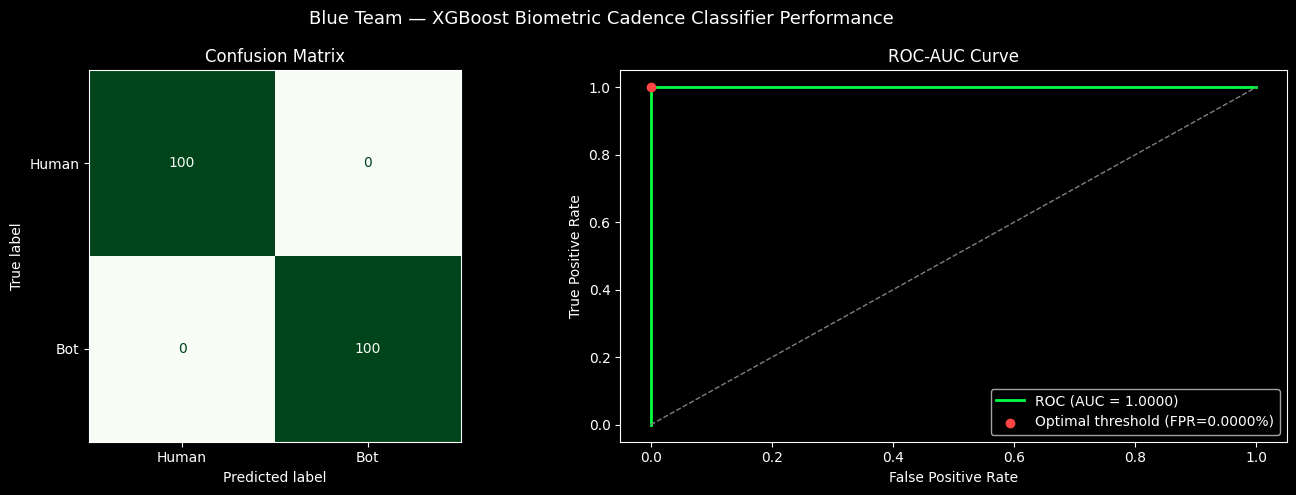

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
fpr_arr, tpr_arr, thresholds = roc_curve(y_test, y_proba)

j_scores   = tpr_arr - fpr_arr
opt_idx    = np.argmax(j_scores)
opt_thresh = thresholds[opt_idx]
opt_fpr    = fpr_arr[opt_idx]

print(f'AUC: {auc:.4f}')
print(f'FPR at optimal threshold ({opt_thresh:.4f}): {opt_fpr*100:.4f}%')
print()
print(classification_report(y_test, y_pred, target_names=['Human', 'Bot']))

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Blue Team — XGBoost Biometric Cadence Classifier Performance', fontsize=13, color='white')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'Bot'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix', color='white')
axes[0].title.set_color('white')

axes[1].plot(fpr_arr, tpr_arr, color='#00FF41', lw=2, label=f'ROC (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1].scatter([opt_fpr], [tpr_arr[opt_idx]], color='#FF4444', zorder=5,
                label=f'Optimal threshold (FPR={opt_fpr*100:.4f}%)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-AUC Curve', color='white')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Section 5 — Co-Evolution Loop
5 epochs: each epoch the Red Team generates 100 improved micro-mimicry sessions with widening behavioral variance to match human patterns. The Blue Team retrains and adapts.

Epoch 0 | AUC: 1.0000 | Evasion Rate: 0.0% | Train size: 800
Epoch 1 | AUC: 1.0000 | Evasion Rate: 11.0% | Train size: 900
Epoch 2 | AUC: 1.0000 | Evasion Rate: 33.0% | Train size: 1000
Epoch 3 | AUC: 1.0000 | Evasion Rate: 48.0% | Train size: 1100
Epoch 4 | AUC: 1.0000 | Evasion Rate: 65.0% | Train size: 1200
Epoch 5 | AUC: 1.0000 | Evasion Rate: 90.0% | Train size: 1300

 Epoch  Train Size    AUC Evasion Rate
     0         800 1.0000         0.0%
     1         900 1.0000        11.0%
     2        1000 1.0000        33.0%
     3        1100 1.0000        48.0%
     4        1200 1.0000        65.0%
     5        1300 1.0000        90.0%


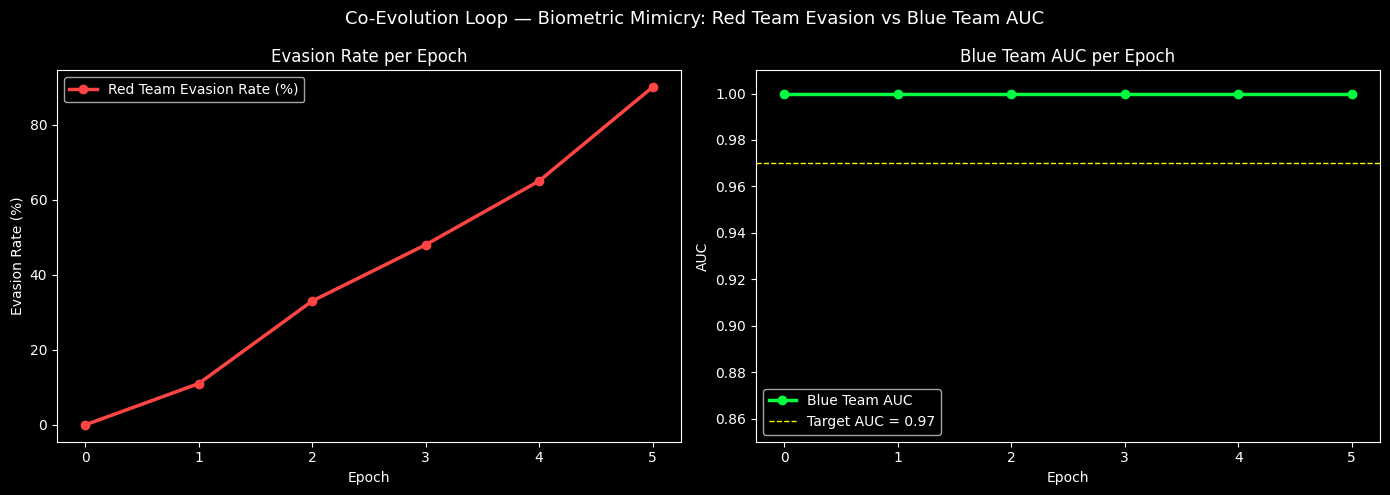

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

np.random.seed(0)

X_train_loop = X_train.copy().tolist()
y_train_loop = y_train.copy().tolist()

evasion_rates = []
auc_scores    = []
epoch_records = []

def make_evasive_biometrics(n=100, epoch=1):
    """Red team refines mimicry each epoch: widening variance toward human ranges."""
    t = epoch / 5.0
    samples = []
    for _ in range(n):
        dwell   = np.clip(np.random.normal(95 + t*25, 8 + t*17), 10, 500)
        flight  = abs(np.random.normal(12 + t*33, 4 + t*11))
        mv_cv   = np.clip(np.random.normal(0.18 + t*0.37, 0.06 + t*0.06), 0.01, 1.5)
        jerk    = np.random.gamma(1.2 + t*1.8, 4 + t*4)
        tp_cv   = np.clip(np.random.normal(0.04 + t*0.18, 0.02 + t*0.05), 0.001, 1.0)
        rhythm  = np.clip(np.random.normal(2.1 + t*1.7, 0.4 + t*0.1), 0.5, 6.0)
        click_r = np.random.beta(max(0.5, 8 - t*6), min(9.5, 2 + t*3))
        dur_z   = np.random.normal(-1.8 + t*1.8, 0.6 + t*0.4)
        samples.append([dwell, flight, mv_cv, jerk, tp_cv, rhythm, click_r, dur_z])
    return np.array(samples)

for epoch in range(6):
    m = HistGradientBoostingClassifier(max_iter=200, max_depth=5, learning_rate=0.1, random_state=epoch)
    m.fit(np.array(X_train_loop), np.array(y_train_loop))

    proba_test = m.predict_proba(X_test)[:, 1]
    epoch_auc  = roc_auc_score(y_test, proba_test)

    if epoch > 0:
        new_adv   = make_evasive_biometrics(100, epoch)
        new_preds = m.predict(new_adv)
        evasion   = 1.0 - new_preds.mean()
        X_train_loop += new_adv.tolist()
        y_train_loop += [1] * len(new_adv)
    else:
        evasion = 0.0

    evasion_rates.append(evasion)
    auc_scores.append(epoch_auc)
    epoch_records.append({
        'Epoch': epoch,
        'Train Size': len(X_train_loop),
        'AUC': f'{epoch_auc:.4f}',
        'Evasion Rate': f'{evasion*100:.1f}%'
    })
    print(f'Epoch {epoch} | AUC: {epoch_auc:.4f} | Evasion Rate: {evasion*100:.1f}% | Train size: {len(X_train_loop)}')

print()
print(pd.DataFrame(epoch_records).to_string(index=False))

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Co-Evolution Loop — Biometric Mimicry: Red Team Evasion vs Blue Team AUC', fontsize=13, color='white')

epochs_range = list(range(6))
axes[0].plot(epochs_range, [r*100 for r in evasion_rates],
             color='#FF4444', lw=2.5, marker='o', label='Red Team Evasion Rate (%)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Evasion Rate (%)')
axes[0].set_title('Evasion Rate per Epoch', color='white')
axes[0].legend()
axes[0].set_xticks(epochs_range)

axes[1].plot(epochs_range, auc_scores,
             color='#00FF41', lw=2.5, marker='o', label='Blue Team AUC')
axes[1].axhline(0.97, color='yellow', lw=1, linestyle='--', label='Target AUC = 0.97')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_title('Blue Team AUC per Epoch', color='white')
axes[1].set_ylim(0.85, 1.01)
axes[1].legend()
axes[1].set_xticks(epochs_range)

plt.tight_layout()
plt.show()